# Check the resolution

- Bring in all the thekla tracks
- cut around ROI
- cut fiducial
- check number of tracks against energy
Do this for each of the differing voxelisations

In [1]:

# import stuff
import sys,os,os.path
import csv
import traceback
#sys.path.append("../../")   # cite IC from parent directory
sys.path.append("/gluster/data/next/software/IC_311024/")
sys.path.append(os.path.expanduser('~/code/eol_hsrl_python'))
sys.path.append("/gluster/data/next/notebooks/")
os.environ['ICTDIR']='/gluster/data/next/software/IC_311024/'

from invisible_cities.core.core_functions   import shift_to_bin_centers
from invisible_cities.io.dst_io           import load_dst, load_dsts, df_writer

import FOM_functions as FOM_func
import functions_HE as func
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd





import scipy.special as special
from scipy.stats import norm
from scipy.stats import skewnorm, crystalball
from scipy.optimize import curve_fit
from tqdm import tqdm

from scipy.integrate import quad

import iminuit
from iminuit import Minuit
import probfit
from concurrent.futures import ProcessPoolExecutor

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import tables as tb
from matplotlib import colors 

from typing          import Optional
from typing          import Union
from typing          import Callable

from concurrent.futures import ProcessPoolExecutor

import sys,os,os.path
from pathlib import Path

from invisible_cities.io.dst_io           import load_dst, load_dsts, df_writer
from invisible_cities.io.hits_io          import hits_writer
from invisible_cities.core                import tbl_functions   as tbl
from invisible_cities.core.core_functions import in_range
#from invisible_cities.cities.beersheba    import hitc_to_df_
from invisible_cities.io.hits_io          import hits_from_df
from invisible_cities.evm.nh5             import HitsTable
from invisible_cities.types.symbols       import NormStrategy
from invisible_cities.types.ic_types      import NoneType
from invisible_cities.reco.corrections    import read_maps, get_df_to_z_converter, apply_all_correction
from invisible_cities.evm.event_model     import HitCollection

from tqdm import tqdm


import traceback

In [2]:
def load_in_data(FOM_TS):
    # load in the data
    CITY = 'thekla'
    #FOM_TS = ['200326_15']
    #FOM_TS = ['201025']
    TIMESTAMP = FOM_TS
    RUN_NUMBER = 'th_port1a_dep_202602_subsample'
    # make directory
    pre_dir = '/gluster/data/next/files/TOPOLOGY_John/MC_data/'
    folder_name = f'{pre_dir}/{RUN_NUMBER}/{CITY}/{FOM_TS[0]}'
    folder_s = Path(f'{folder_name}')

    print(folder_s)

    tdst = []
    for LDC in tqdm(range(1,8)):
        files = list(Path(f'{folder_name}/ldc{LDC}/').rglob('*.h5'))
        for file in tqdm(files):
            try:
                df = load_dst(file, 'Tracking', 'Tracks')
            except:
                traceback.format_exc()
                df = pd.DataFrame()
            tdst.append(df)

    tdst = pd.concat(tdst)
    display(tdst)
    return tdst

tdst = load_in_data(['200326_15'])

/gluster/data/next/files/TOPOLOGY_John/MC_data/th_port1a_dep_202602_subsample/thekla/200326_15


  0%|          | 0/7 [00:00<?, ?it/s]

100%|██████████| 7/7 [01:10<00:00, 10.01s/it]


,event,trackID,energy,length,numb_of_voxels,numb_of_hits,numb_of_tracks,x_min,y_min,z_min,...,blob1_z,blob2_x,blob2_y,blob2_z,eblob1,eblob2,ovlp_blob_energy,vox_size_x,vox_size_y,vox_size_z
0,11600000,0,1.621389,280.572478,246,648,1,244.725,45.275,433.455016,...,467.635405,291.375,231.875,494.129022,0.585000,0.320811,0.000000,14.439286,14.578125,13.816127
1,11600001,0,1.595271,258.113725,320,783,1,-159.575,-296.825,1029.436309,...,1110.375827,-97.375,-125.775,1051.628786,0.518094,0.328262,0.000000,14.136364,14.513333,14.849937
2,11600002,0,1.599760,259.661123,292,758,2,229.175,107.475,658.791568,...,757.432640,291.375,262.975,667.828899,0.478190,0.450183,0.000000,14.254167,14.635294,14.810985
3,11600002,1,0.034830,35.065005,5,10,2,338.025,325.175,586.629581,...,589.958636,353.575,325.175,589.958636,0.034830,0.034830,0.034830,14.254167,14.635294,14.810985
4,11600003,0,1.568411,203.143765,330,850,1,-206.225,-265.725,972.093848,...,1021.532432,-144.025,-125.775,1049.923761,0.818197,0.222974,0.000000,13.822222,14.353846,13.851534
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
227,412200166,0,1.601410,290.774412,294,753,2,213.625,-390.125,982.512315,...,1088.868906,369.125,-250.175,997.555235,0.445046,0.162027,0.000000,14.843182,14.963208,14.760521
228,412200166,1,0.124920,80.449198,19,41,2,73.675,340.725,786.028307,...,792.592384,104.775,371.825,792.592384,0.123181,0.123181,0.123181,14.843182,14.963208,14.760521
229,412200167,0,1.514719,345.782452,293,708,2,-283.975,154.125,528.594056,...,558.848618,-66.275,200.775,650.518193,0.246459,0.150028,0.000000,14.731579,14.353846,14.805057
230,412200167,1,0.028646,43.061538,7,10,2,-159.575,154.125,478.712824,...,478.712824,-159.575,154.125,478.712824,0.026276,0.026276,0.026276,14.731579,14.353846,14.805057


In [12]:
# summary
def make_summary(df):
    print('=' * 20)
    print(f'Events: {df.event.nunique()}')
    plt.hist2d(df.numb_of_tracks, df.energy, bins = (20, 50))
    plt.xlabel('Number of tracks')
    plt.ylabel('Energy (MeV)')
    plt.show()
    plt.hist(df.groupby('event').energy.sum())
    plt.xlabel('Energy (MeV)')
    plt.ylabel('counts')
    plt.show()
    print('=' * 20)

Events: 202053


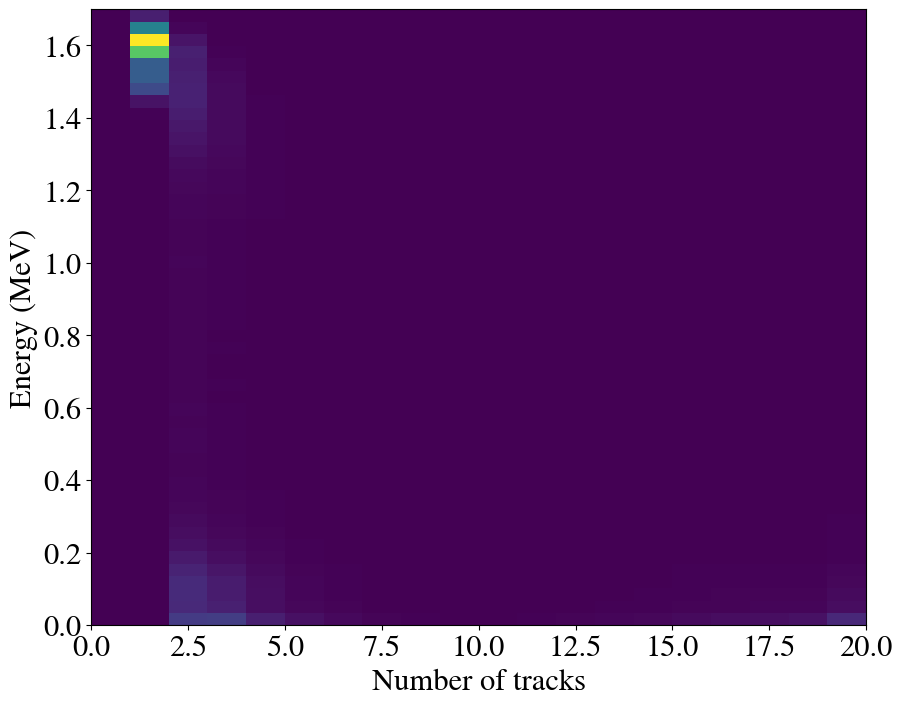

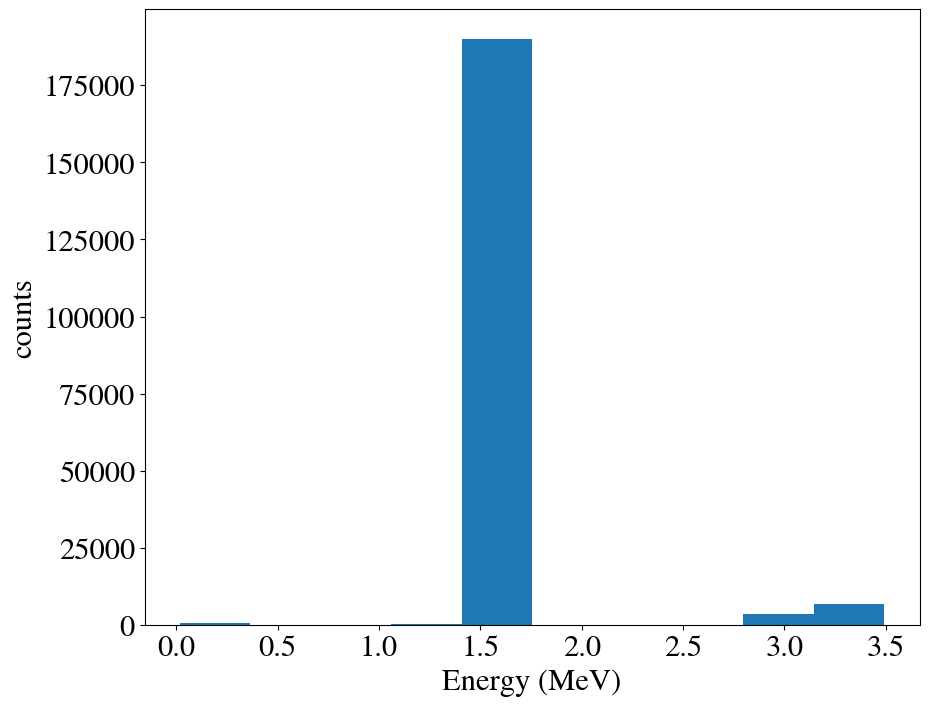

In [4]:
make_summary(tdst)

event
1200000      1.534548
1200001      1.609858
1200002      1.595395
1200003      1.618707
1200004      1.522317
               ...   
992000171    1.526024
992000172    1.656308
992000173    1.594356
992000174    1.574032
992000175    1.622928
Name: energy, Length: 167742, dtype: float64
Events: 167742


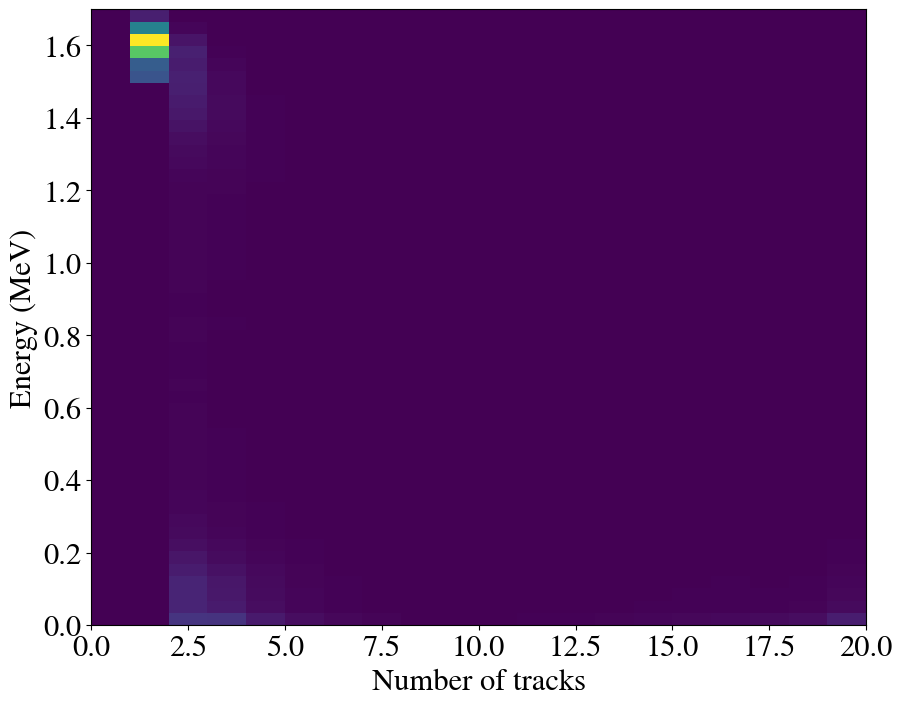

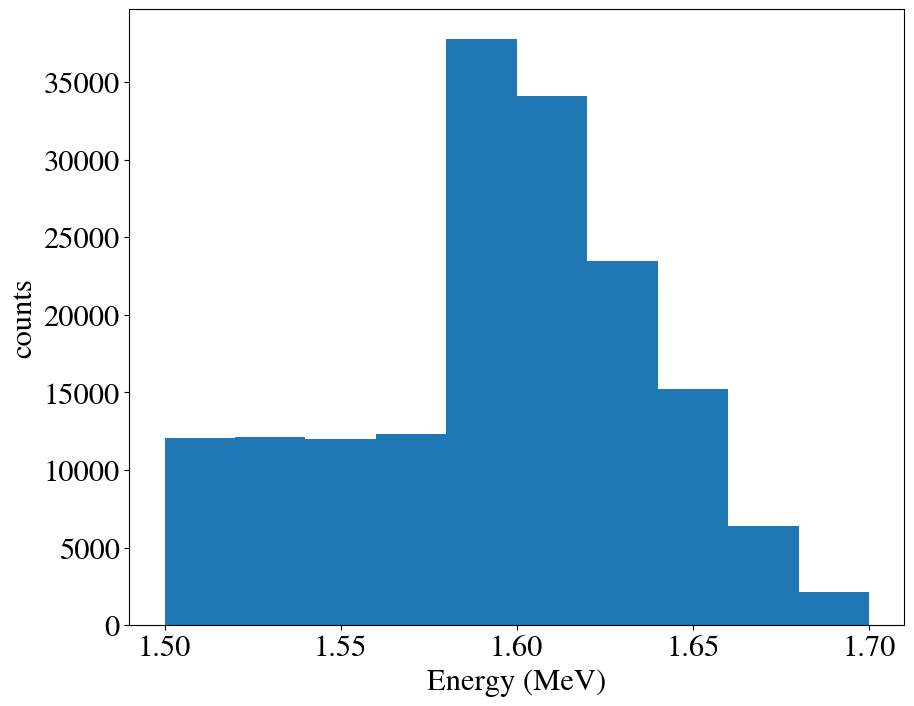

In [5]:
lower_E = 1.5
upper_E = 1.7

# cut energy-wise
tdst_sum_pE = tdst.groupby('event').energy.sum() 
tdst_sum_pE_cut = tdst_sum_pE[(tdst_sum_pE.values >= lower_E) & (tdst_sum_pE.values <= upper_E)]  
print(tdst_sum_pE_cut)
ROI_tdst = tdst[tdst.event.isin(tdst_sum_pE_cut.index)]
make_summary(ROI_tdst)

Events: 21600


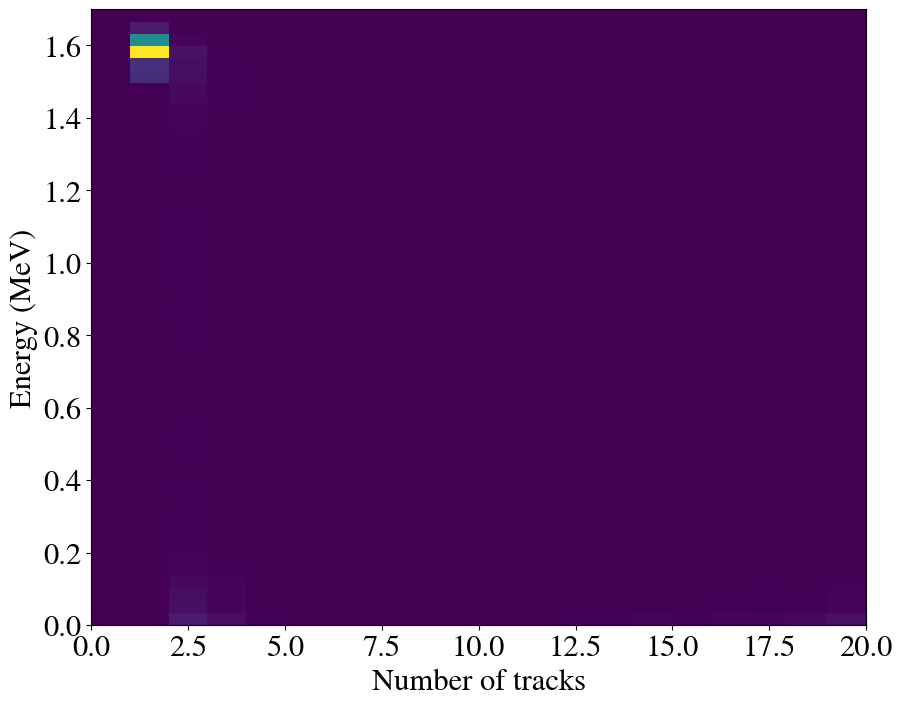

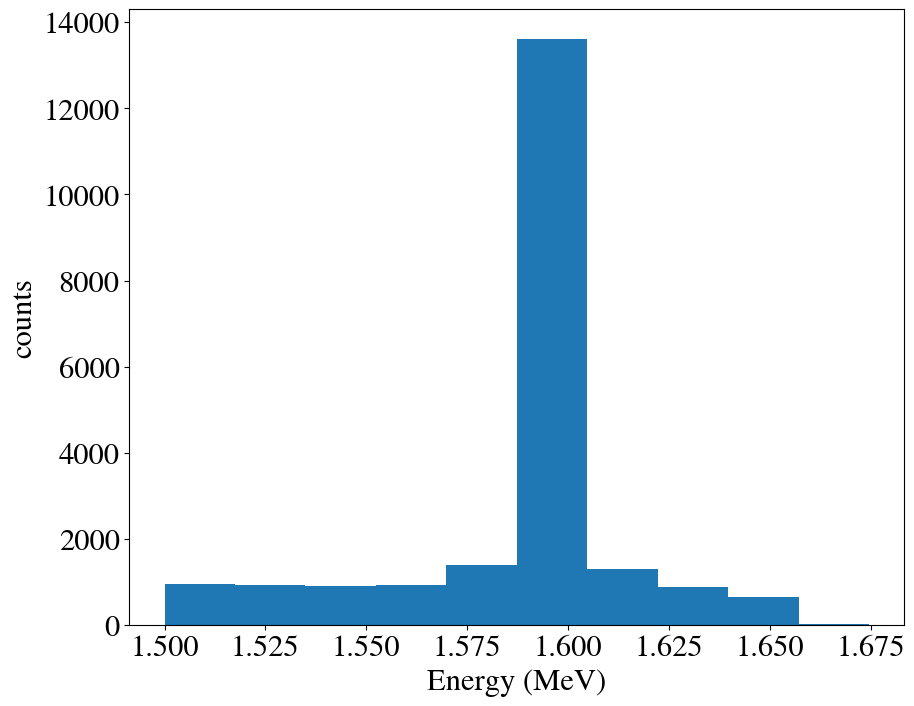

In [6]:
fid_tdst = func.fiducial_track_cut_2(ROI_tdst, r_lim = 300, lower_z = 20, upper_z = 1170)
make_summary(fid_tdst)

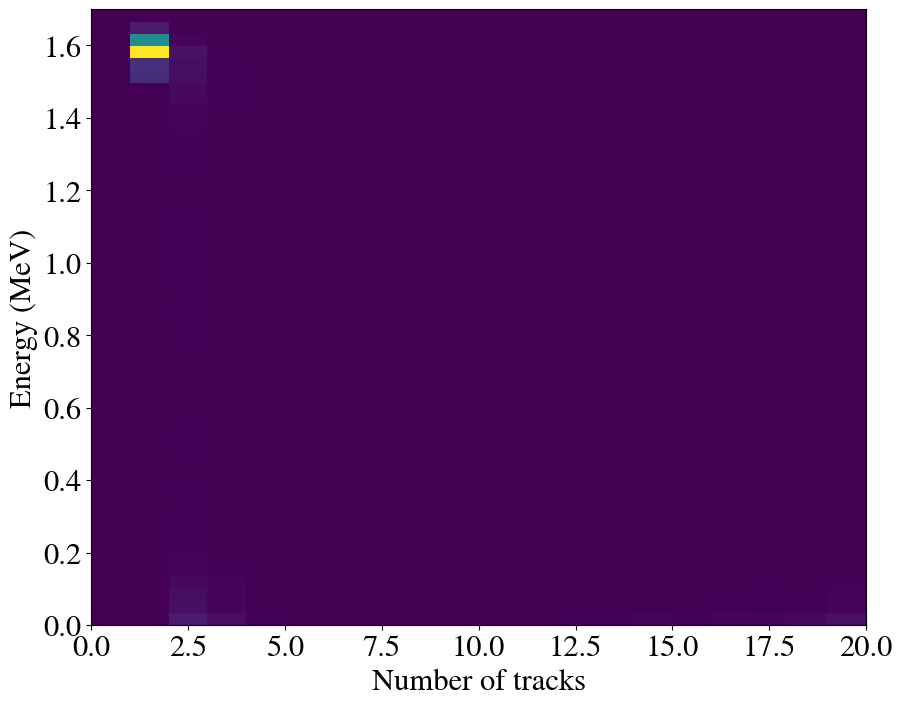

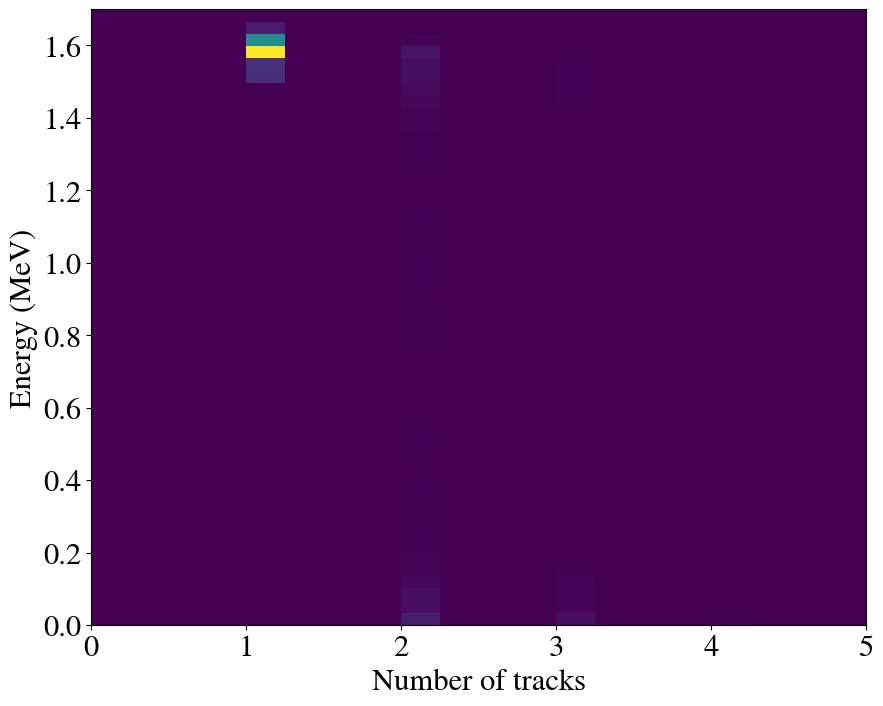

Number of 1-tracks after all cuts: 18151


In [7]:
# plot the number of tracks against energy
plt.hist2d(fid_tdst.numb_of_tracks, fid_tdst.energy, bins = (20, 50), range = ([0, 20], [0, 1.7]))
plt.xlabel('Number of tracks')
plt.ylabel('Energy (MeV)')
plt.show()

# plot the number of tracks against energy
plt.hist2d(fid_tdst.numb_of_tracks, fid_tdst.energy, bins = (20, 50), range = ([0, 5], [0, 1.7]))
plt.xlabel('Number of tracks')
plt.ylabel('Energy (MeV)')
plt.show()

print(f'Number of 1-tracks after all cuts: {fid_tdst[fid_tdst.numb_of_tracks == 1].event.nunique()}')


In [17]:
def visualise_tracks(df, 
                     lower_E = 1.5, 
                     upper_E = 1.7,
                     r_lim   = 300,
                     lower_z = 20,
                     upper_z = 1170):

    make_summary(df)
    # cut energy-wise
    tdst_sum_pE = df.groupby('event').energy.sum() 
    tdst_sum_pE_cut = tdst_sum_pE[(tdst_sum_pE.values >= lower_E) & (tdst_sum_pE.values <= upper_E)]  
    print(tdst_sum_pE_cut)
    ROI_tdst = df[df.event.isin(tdst_sum_pE_cut.index)]
    print('Post energy cut:')
    make_summary(ROI_tdst)
    
    print(f'Number of 1-tracks after ROI cuts: {ROI_tdst[ROI_tdst.numb_of_tracks == 1].event.nunique()}')

    fid_tdst = func.fiducial_track_cut_2(ROI_tdst, r_lim, lower_z, upper_z)
    print('Post fiducial cut:')
    make_summary(fid_tdst)
    
    # plot the number of tracks against energy
    plt.hist2d(fid_tdst.numb_of_tracks, fid_tdst.energy, bins = (20, 50), range = ([0, 50], [0, 1.7]))
    plt.xlabel('Number of tracks')
    plt.ylabel('Energy (MeV)')
    plt.show()

    # plot the number of tracks against energy
    plt.hist2d(fid_tdst.numb_of_tracks, fid_tdst.energy, bins = (20, 50), range = ([0, 5], [0, 1.7]))
    plt.xlabel('Number of tracks')
    plt.ylabel('Energy (MeV)')
    plt.show()

    
    print(f'Number of 1-tracks after all cuts: {fid_tdst[fid_tdst.numb_of_tracks == 1].event.nunique()}')

12mm
/gluster/data/next/files/TOPOLOGY_John/MC_data/th_port1a_dep_202602_subsample/thekla/200326_12


100%|██████████| 210/210 [00:06<00:00, 30.39it/s]
0it [00:00, ?it/s]/7 [00:50<00:08,  8.03s/it]
100%|██████████| 7/7 [00:50<00:00,  7.22s/it]


,event,trackID,energy,length,numb_of_voxels,numb_of_hits,numb_of_tracks,x_min,y_min,z_min,...,blob1_z,blob2_x,blob2_y,blob2_z,eblob1,eblob2,ovlp_blob_energy,vox_size_x,vox_size_y,vox_size_z
0,152900000,0,0.178790,51.043396,30,78,23,275.825,-250.175,666.447894,...,675.745675,291.375,-234.625,675.745675,0.178790,0.178790,0.178790,11.961538,11.457895,11.130738
1,152900000,1,0.168856,62.174134,33,73,23,229.175,-203.525,670.059047,...,699.028582,244.725,-203.525,699.028582,0.161660,0.161660,0.161660,11.961538,11.457895,11.130738
2,152900000,2,0.163296,69.687812,34,85,23,229.175,-250.175,666.447894,...,697.945701,244.725,-219.075,698.602577,0.161440,0.141658,0.139803,11.961538,11.457895,11.130738
3,152900000,3,0.162171,51.874197,25,58,23,166.975,-203.525,694.245808,...,709.236217,198.075,-203.525,709.236217,0.161367,0.161367,0.161367,11.961538,11.457895,11.130738
4,152900000,4,0.119560,47.061317,23,51,23,384.675,-250.175,635.220767,...,642.929294,400.225,-219.075,642.929294,0.091661,0.091661,0.091661,11.961538,11.457895,11.130738
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3717,551200193,14,0.010745,16.274313,4,7,19,151.425,387.375,411.549830,...,422.020388,151.425,402.925,422.020388,0.010745,0.010745,0.010745,11.493478,11.961538,11.035164
3718,551200193,15,0.010130,16.274313,3,6,19,229.175,387.375,359.489247,...,362.266141,229.175,387.375,362.266141,0.010130,0.010130,0.010130,11.493478,11.961538,11.035164
3719,551200193,16,0.003706,0.000000,1,1,19,275.825,387.375,466.871471,...,466.871471,275.825,387.375,466.871471,0.003706,0.003706,0.003706,11.493478,11.961538,11.035164
3720,551200193,17,0.002728,11.493478,2,2,19,198.075,387.375,394.121636,...,394.121636,198.075,387.375,394.121636,0.002728,0.002728,0.002728,11.493478,11.961538,11.035164


Events: 188587


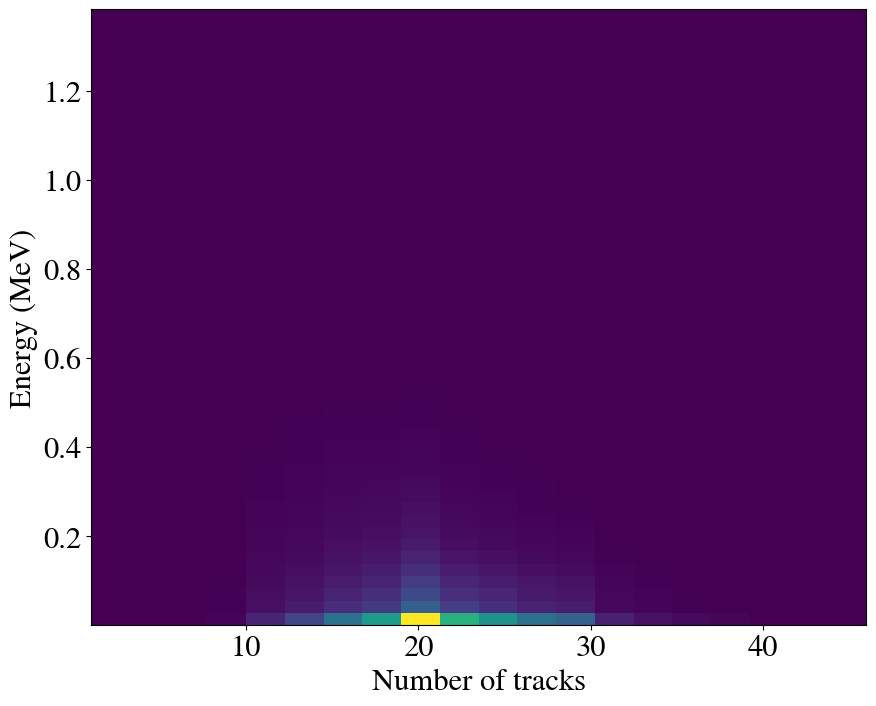

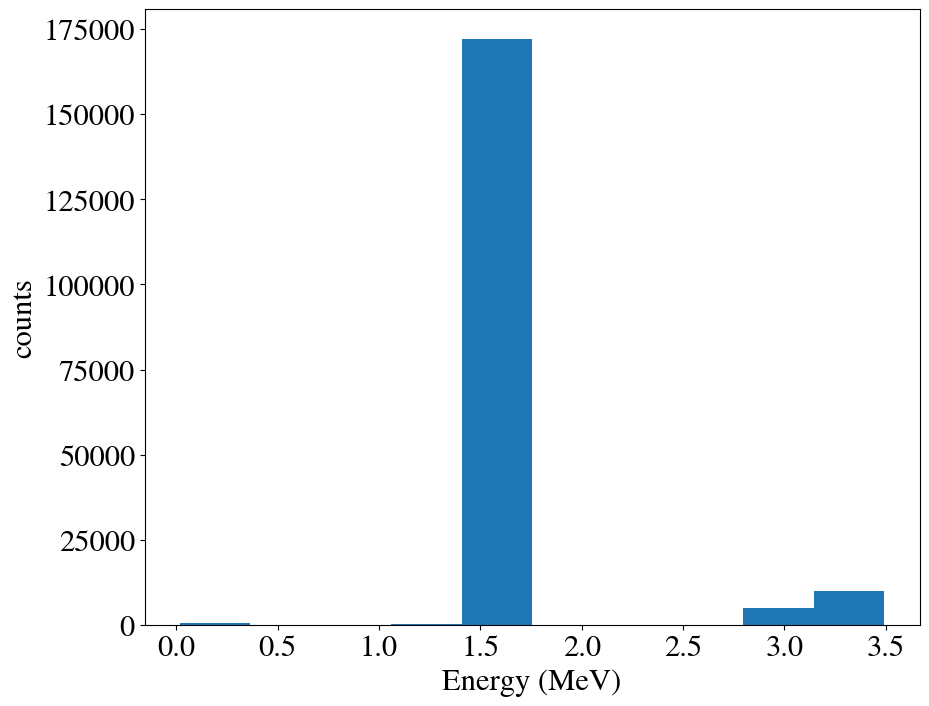

event
1200000      1.534548
1200001      1.609858
1200002      1.595395
1200003      1.618707
1200004      1.522317
               ...   
992000171    1.526024
992000172    1.656308
992000173    1.594356
992000174    1.574032
992000175    1.622928
Name: energy, Length: 151959, dtype: float64
Post energy cut:
Events: 151959


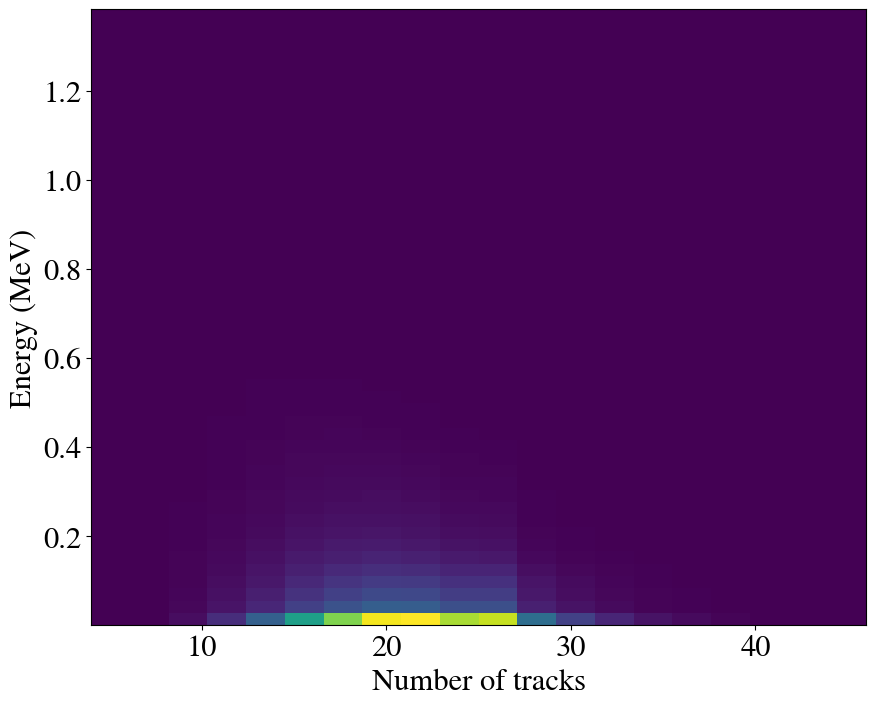

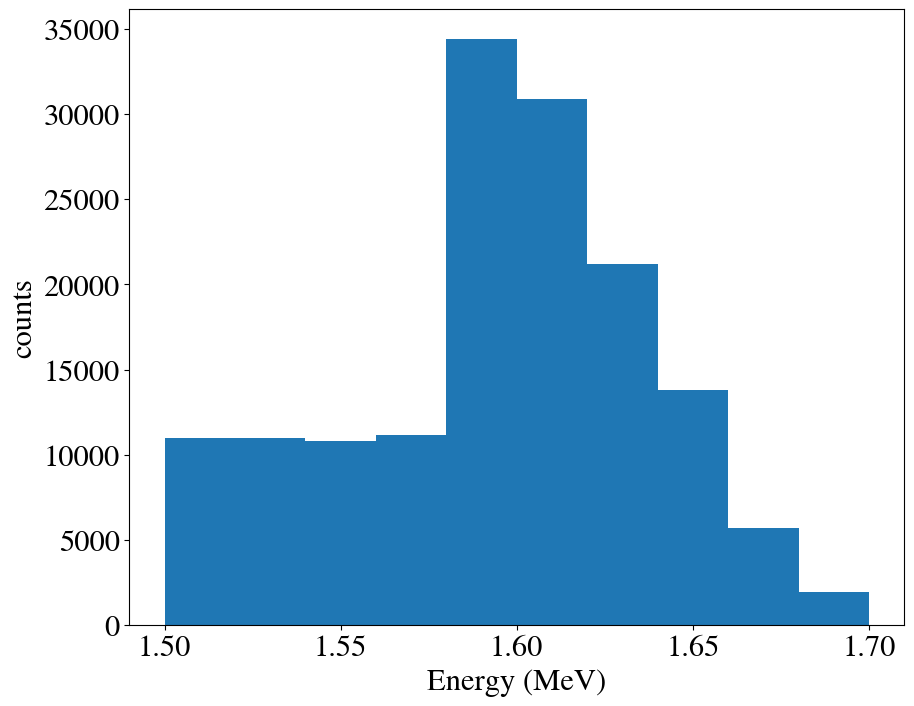

Number of 1-tracks after ROI cuts: 0
Post fiducial cut:
Events: 0


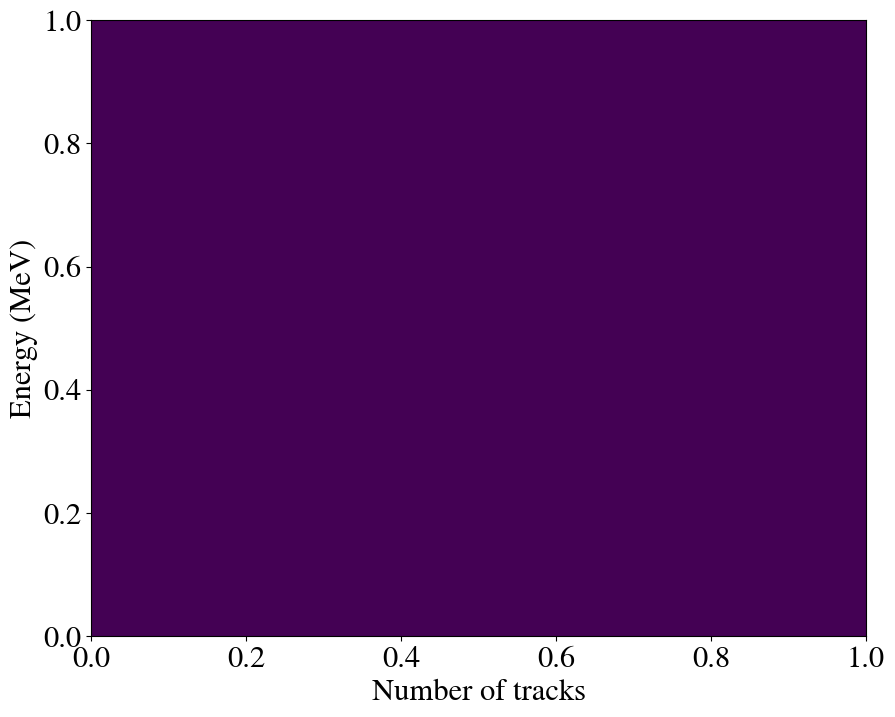

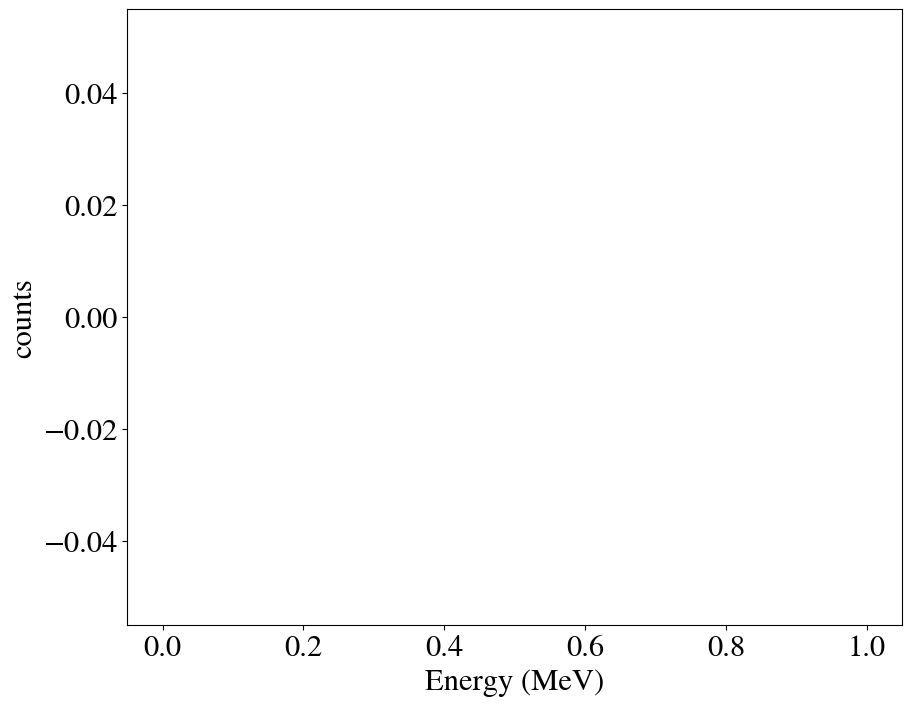

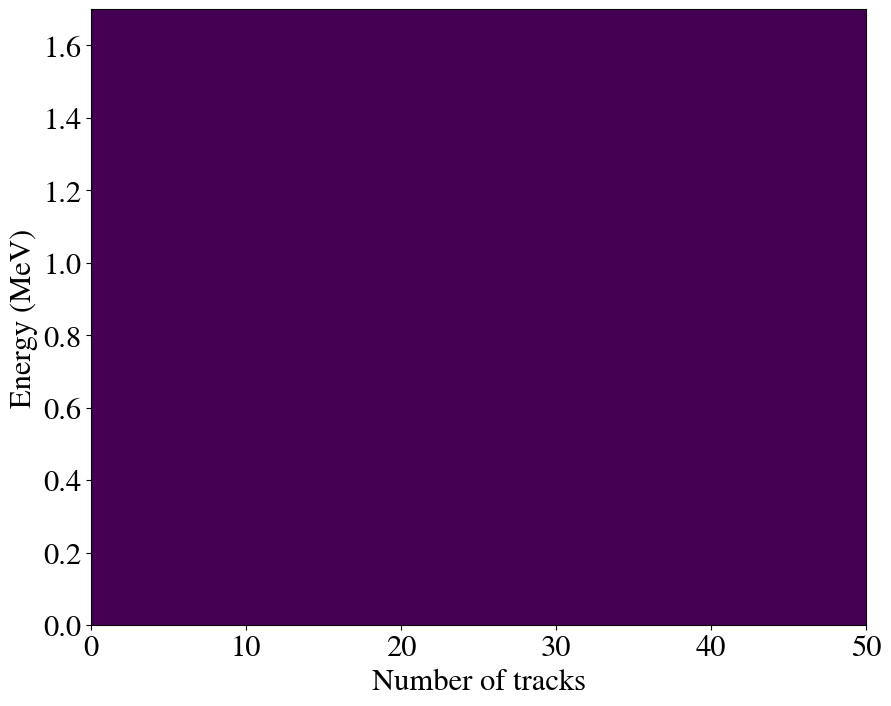

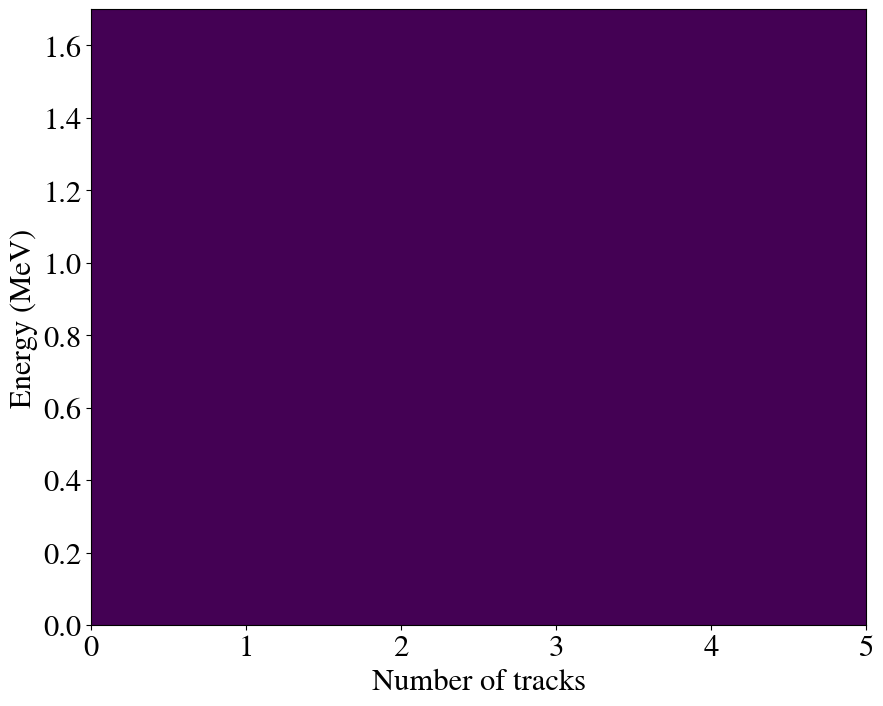

Number of 1-tracks after all cuts: 0
9mm
/gluster/data/next/files/TOPOLOGY_John/MC_data/th_port1a_dep_202602_subsample/thekla/200326_9


100%|██████████| 7/7 [01:39<00:00, 14.18s/it]


,event,trackID,energy,length,numb_of_voxels,numb_of_hits,numb_of_tracks,x_min,y_min,z_min,...,blob1_z,blob2_x,blob2_y,blob2_z,eblob1,eblob2,ovlp_blob_energy,vox_size_x,vox_size_y,vox_size_z
0,115600000,0,0.206507,101.039004,34,69,72,73.675,-483.425,39.059041,...,73.701685,73.675,-467.875,99.302367,0.155564,0.122188,0.075433,8.638889,8.789130,8.528851
1,115600000,1,0.161040,37.833597,8,18,72,120.325,-359.025,150.610594,...,160.557183,120.325,-359.025,160.557183,0.161040,0.161040,0.161040,8.638889,8.789130,8.528851
2,115600000,2,0.095339,37.833597,9,16,72,104.775,-359.025,150.610594,...,175.641464,104.775,-359.025,175.641464,0.095339,0.095339,0.095339,8.638889,8.789130,8.528851
3,115600000,3,0.083136,29.304746,7,15,72,135.875,-359.025,157.410962,...,167.742796,135.875,-343.475,167.742796,0.083136,0.083136,0.083136,8.638889,8.789130,8.528851
4,115600000,4,0.055636,54.783927,13,26,72,73.675,-452.325,105.542242,...,132.607236,73.675,-452.325,132.607236,0.055636,0.055636,0.055636,8.638889,8.789130,8.528851
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13012,412300147,75,0.000789,0.000000,1,1,80,229.175,169.675,722.296511,...,722.296511,229.175,169.675,722.296511,0.000789,0.000789,0.000789,8.746875,8.638889,8.785708
13013,412300147,76,0.000771,0.000000,1,1,80,244.725,262.975,694.300346,...,694.300346,244.725,262.975,694.300346,0.000771,0.000771,0.000771,8.746875,8.638889,8.785708
13014,412300147,77,0.000718,0.000000,1,1,80,198.075,231.875,729.085067,...,729.085067,198.075,231.875,729.085067,0.000718,0.000718,0.000718,8.746875,8.638889,8.785708
13015,412300147,78,0.000661,0.000000,1,1,80,213.625,294.075,725.705334,...,725.705334,213.625,294.075,725.705334,0.000661,0.000661,0.000661,8.746875,8.638889,8.785708


Events: 218363


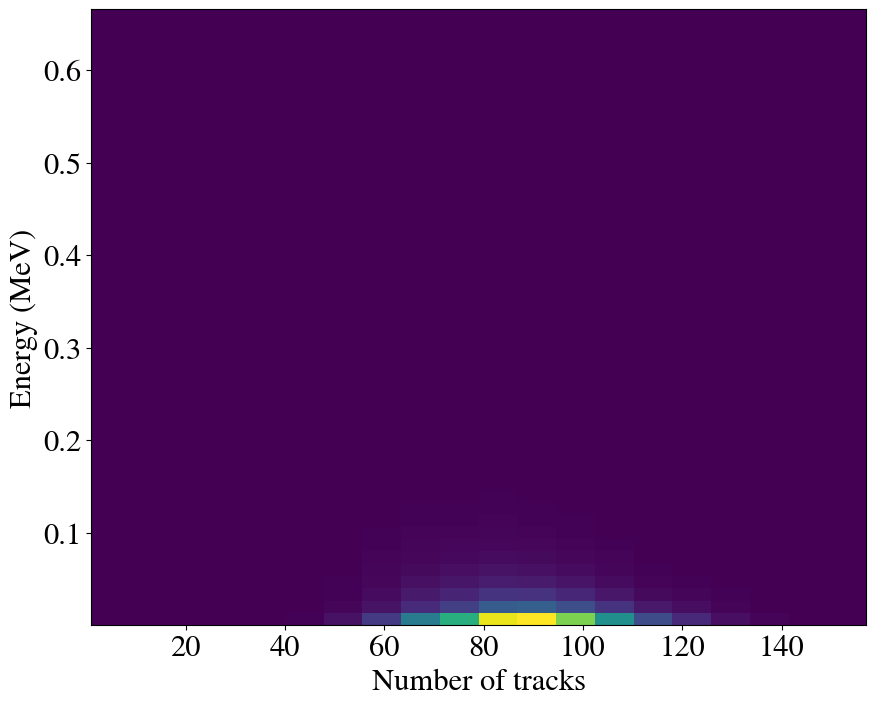

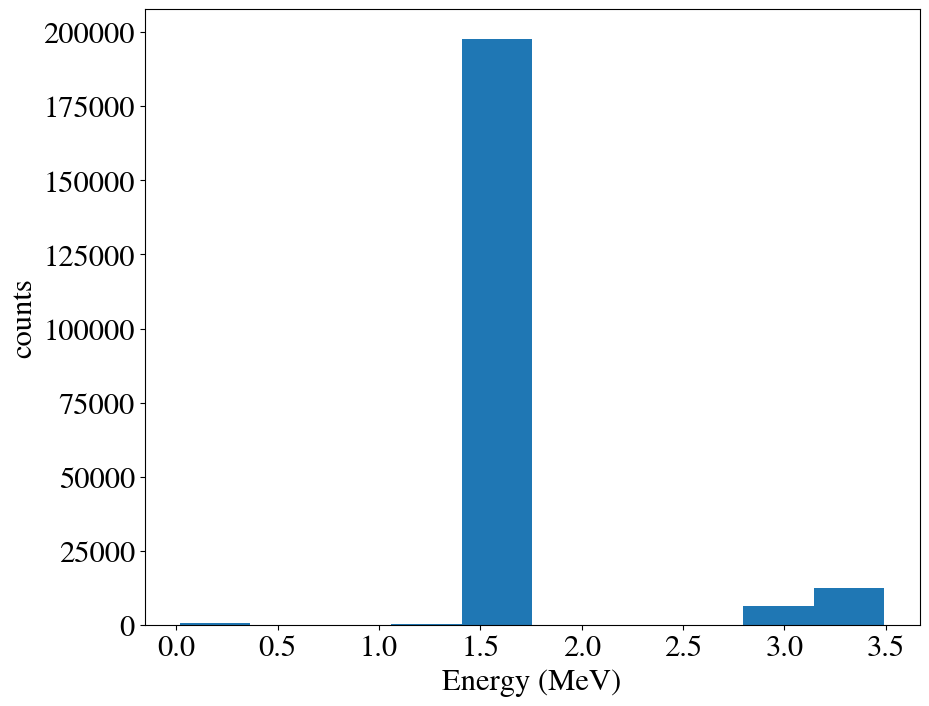

event
1200000      1.534548
1200001      1.609858
1200002      1.595395
1200003      1.618707
1200004      1.522317
               ...   
992000171    1.526024
992000172    1.656308
992000173    1.594356
992000174    1.574032
992000175    1.622928
Name: energy, Length: 174593, dtype: float64
Post energy cut:
Events: 174593


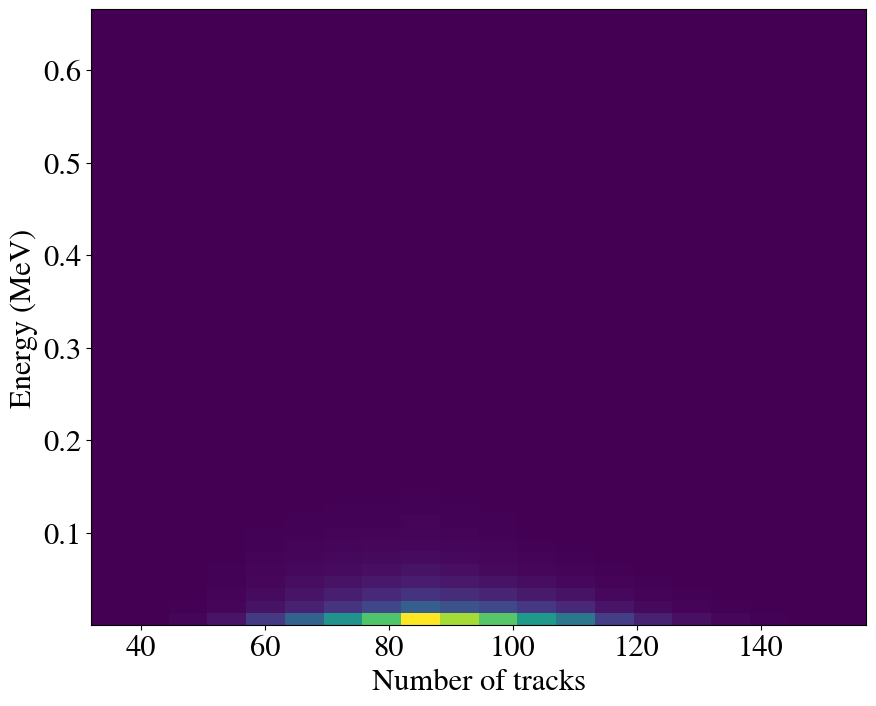

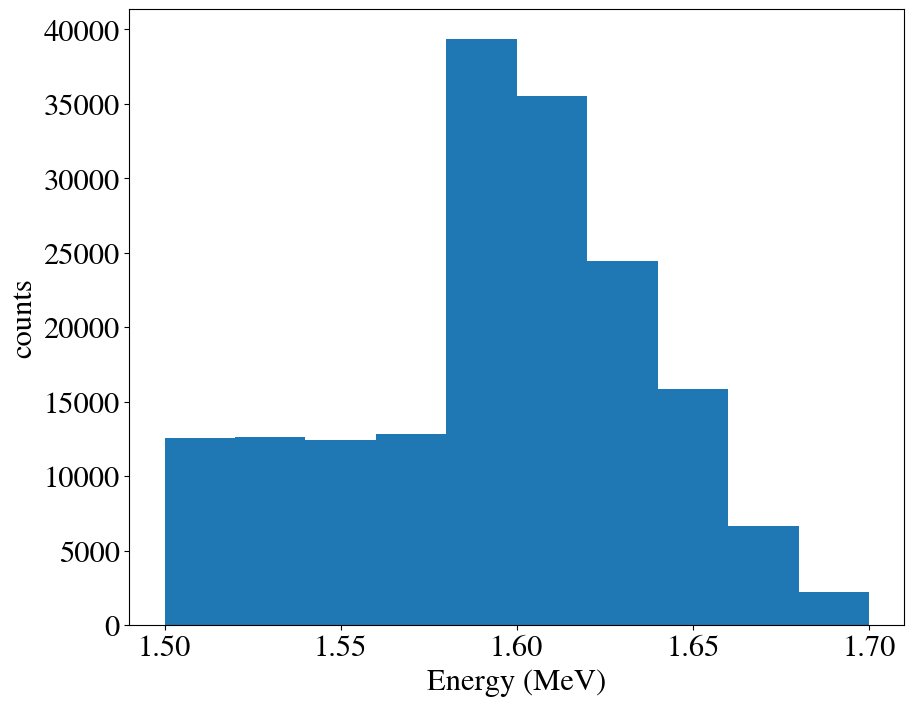

Number of 1-tracks after ROI cuts: 0
Post fiducial cut:
Events: 0


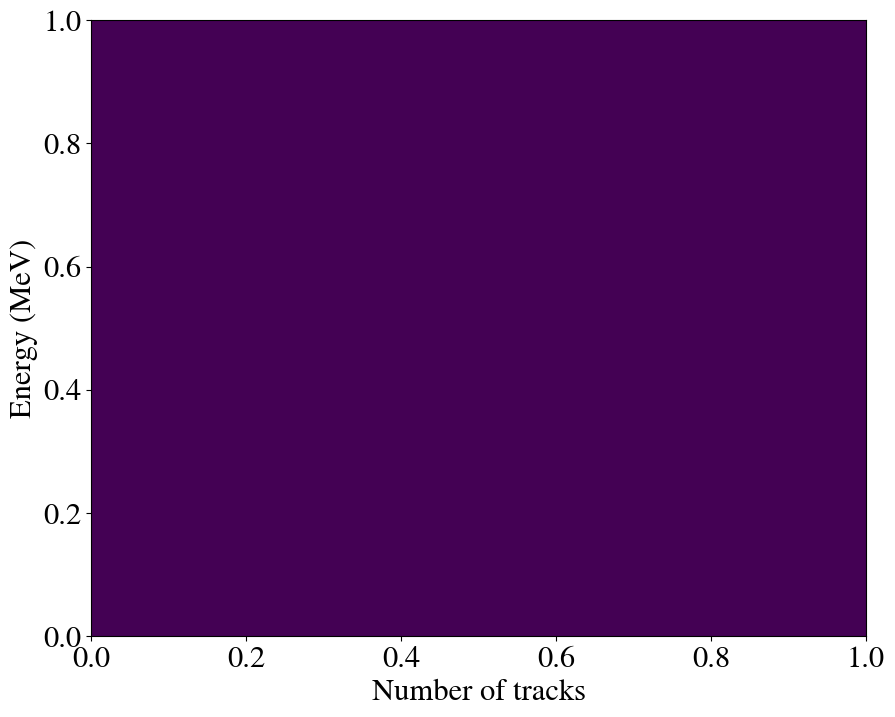

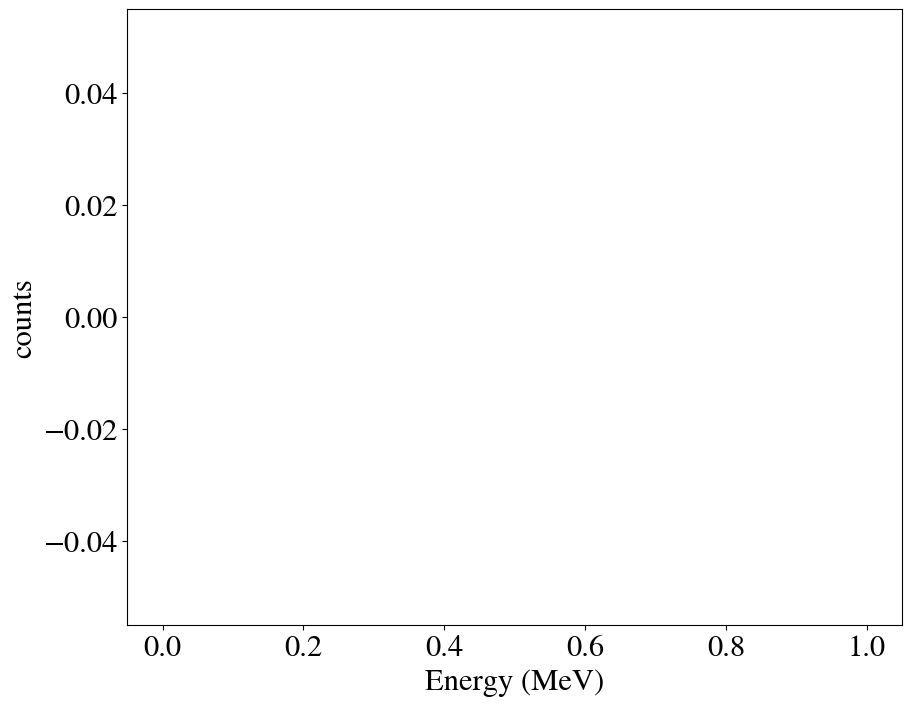

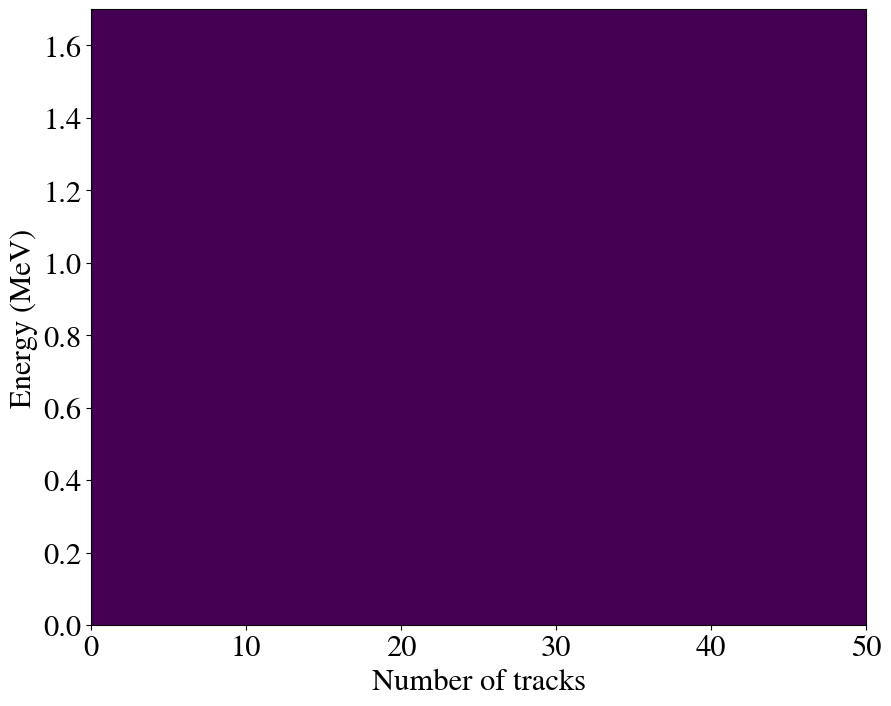

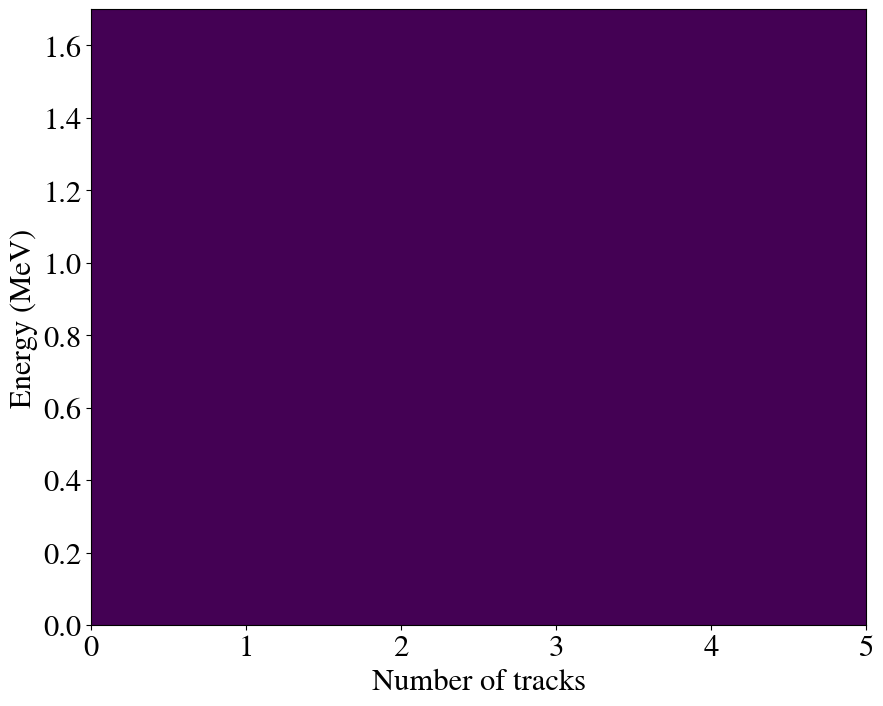

Number of 1-tracks after all cuts: 0


In [18]:
print('='*20)
print(f'12mm')
print('='*20)
tdst = load_in_data(['200326_12'])
visualise_tracks(tdst)

print('='*20)
print(f'9mm')
print('='*20)
tdst = load_in_data(['200326_9'])
visualise_tracks(tdst)